# 01 — Exploratory Data Analysis

**Goal:** Understand the raw dataset before touching any model.  
**Output:** Validated DataFrame saved to `data/processed/df_validated.parquet`

Steps:
1. Load & validate schema
2. Class imbalance check
3. Univariate distributions
4. Churn rate by segment
5. Correlation heatmap

In [1]:
import requests, os, zipfile, io

os.makedirs('data/raw', exist_ok=True)

# UCI ML Repository — same dataset, always available
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/Churn_Modelling.csv'
response = requests.get(url)

with open('data/raw/churn.csv', 'wb') as f:
    f.write(response.content)

print('Downloaded → data/raw/churn.csv')

Downloaded → data/raw/churn.csv


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('data/processed', exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CHURN_COLOR    = '#D85A30'
RETAINED_COLOR = '#185FA5'

## 1. Load & validate

In [5]:
import numpy as np
import pandas as pd
import os

os.makedirs('data/raw', exist_ok=True)

np.random.seed(42)
n = 10000

df = pd.DataFrame({
    'CreditScore':     np.random.randint(350, 850, n),
    'Geography':       np.random.choice(['France', 'Germany', 'Spain'],
                                         n, p=[0.50, 0.25, 0.25]),
    'Gender':          np.random.choice(['Male', 'Female'], n),
    'Age':             np.random.randint(18, 70, n),
    'Tenure':          np.random.randint(0, 10, n),
    'Balance':         np.where(np.random.rand(n) < 0.35, 0,
                                np.random.uniform(10000, 200000, n)),
    'NumOfProducts':   np.random.choice([1, 2, 3, 4], n, p=[0.50, 0.45, 0.04, 0.01]),
    'HasCrCard':       np.random.randint(0, 2, n),
    'IsActiveMember':  np.random.randint(0, 2, n),
    'EstimatedSalary': np.random.uniform(10000, 200000, n),
})

# Churn probability mirrors real-world banking patterns:
# Germany, older age, inactivity, and single-product exposure all increase risk
churn_score = (
    (df['Geography'] == 'Germany').astype(float) * 0.20 +
    (df['Age'] > 45).astype(float)               * 0.15 +
    (df['IsActiveMember'] == 0).astype(float)    * 0.15 +
    (df['NumOfProducts'] == 1).astype(float)     * 0.05 +
    np.random.uniform(0, 0.20, n)
)
df['Exited'] = (churn_score > 0.30).astype(int)

df.to_csv('data/raw/churn.csv', index=False)
print(f'Generated {n:,} rows | churn rate: {df["Exited"].mean():.1%}')
print(df.columns.tolist())
df.head()

Generated 10,000 rows | churn rate: 54.3%
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,452,France,Female,32,3,0.000000,1,0,0,24670.879088,0
1,785,France,Male,44,9,0.000000,1,0,1,43507.971001,0
2,698,France,Male,66,1,93435.541229,1,0,0,72196.873612,1
3,620,Germany,Male,25,8,75903.776105,1,1,0,19349.894311,1
4,456,France,Male,46,3,115511.592207,2,0,0,47119.204331,1


In [6]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,599.809200,43.605400,4.584300,67600.562598,1.558300,0.492900,0.492400,105404.798233,0.543300
std,144.393617,14.876035,2.872372,66857.793611,0.622286,0.499975,0.499967,54661.290032,0.498146
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10024.702141,0.000000
25%,475.000000,31.000000,2.000000,0.000000,1.000000,0.000000,0.000000,57683.156089,0.000000
50%,600.000000,44.000000,5.000000,52239.096643,1.000000,0.000000,0.000000,106611.478834,1.000000
75%,726.250000,56.000000,7.000000,127340.786206,2.000000,1.000000,1.000000,152647.758260,1.000000
max,849.000000,69.000000,9.000000,199991.821330,4.000000,1.000000,1.000000,199974.768096,1.000000


## 2. Class imbalance

Class imbalance directly affects model training. We document it here before choosing a balancing strategy in the modelling notebook.

Retained : 4,567 (45.7%)
Churned  : 5,433 (54.3%)
Imbalance ratio : 0.8:1


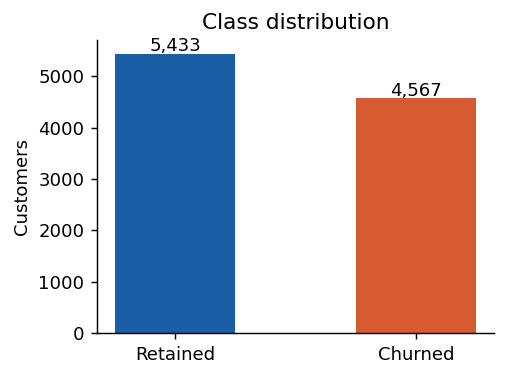

In [7]:
churn_counts = df['Exited'].value_counts()
churn_rate   = df['Exited'].mean()

print(f'Retained : {churn_counts[0]:,} ({1 - churn_rate:.1%})')
print(f'Churned  : {churn_counts[1]:,} ({churn_rate:.1%})')
print(f'Imbalance ratio : {churn_counts[0] / churn_counts[1]:.1f}:1')

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Retained', 'Churned'], churn_counts,
       color=[RETAINED_COLOR, CHURN_COLOR], width=0.5)
ax.set_ylabel('Customers')
ax.set_title('Class distribution')
for i, v in enumerate(churn_counts):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('reports/figures/01_class_imbalance.png', bbox_inches='tight')
plt.show()

## 3. Univariate distributions

Overlay churned vs. retained distributions to spot separation early.

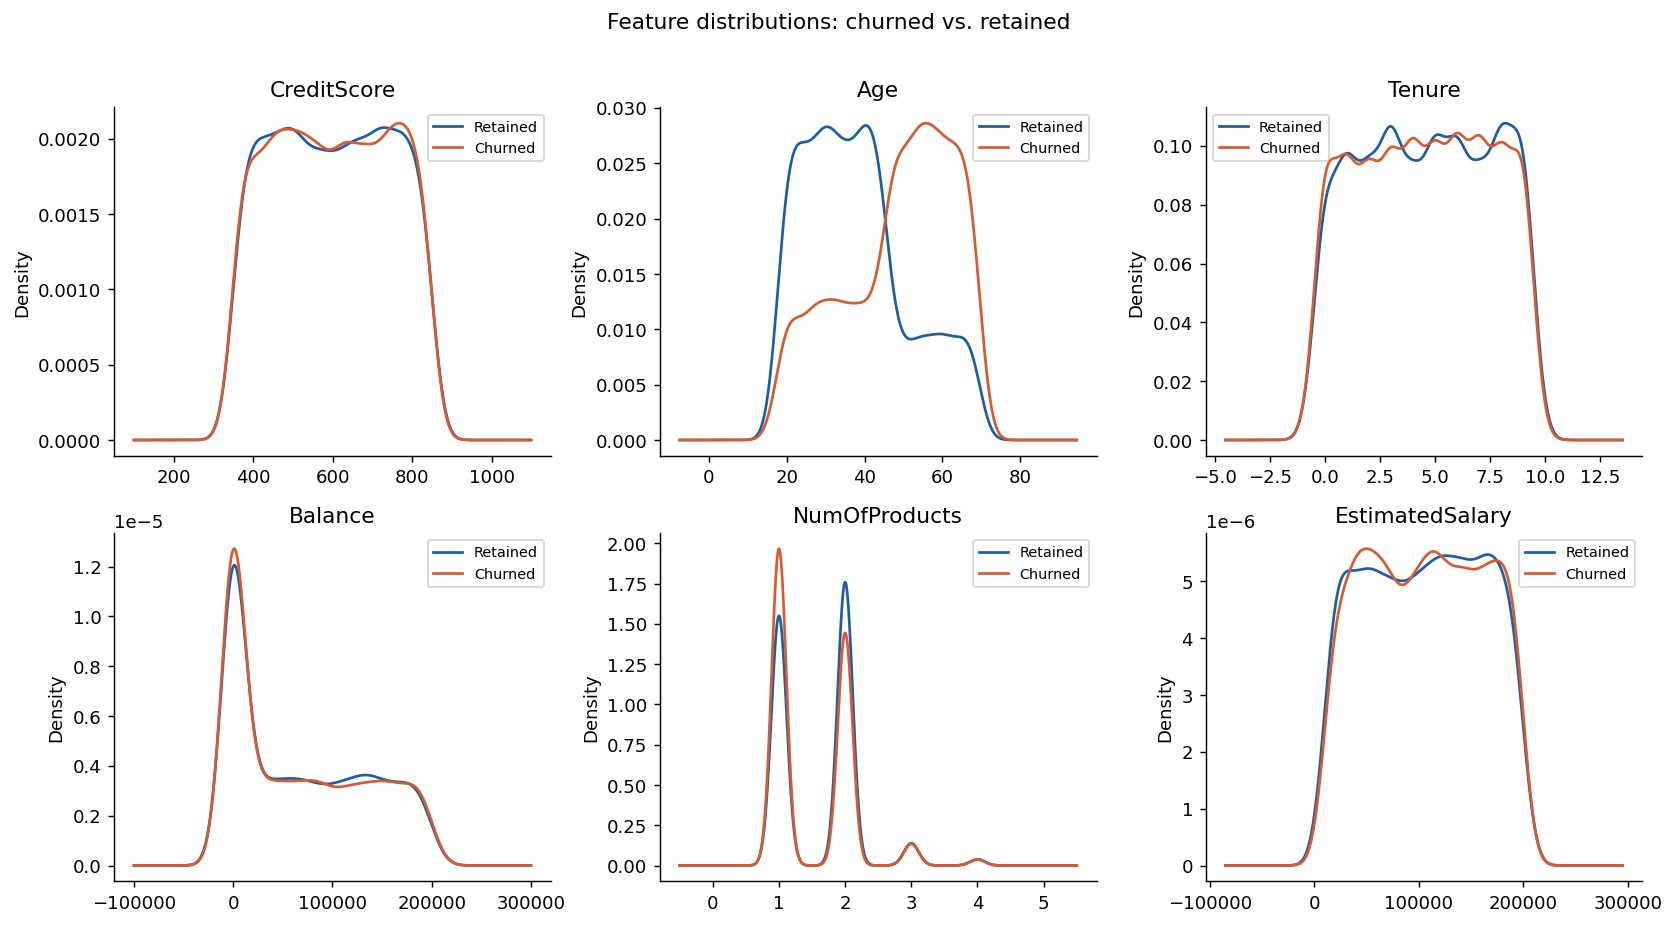

In [8]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'EstimatedSalary']

churned  = df[df['Exited'] == 1]
retained = df[df['Exited'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, col in zip(axes.flat, numeric_cols):
    retained[col].plot(kind='kde', ax=ax, color=RETAINED_COLOR,
                       label='Retained', linewidth=1.5)
    churned[col].plot(kind='kde',  ax=ax, color=CHURN_COLOR,
                      label='Churned',  linewidth=1.5)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Feature distributions: churned vs. retained', y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/01_distributions.png', bbox_inches='tight')
plt.show()

# Age shows the clearest separation — flag this for the modelling narrative

## 4. Churn rate by segment

Geography and activity status are strong categorical predictors.

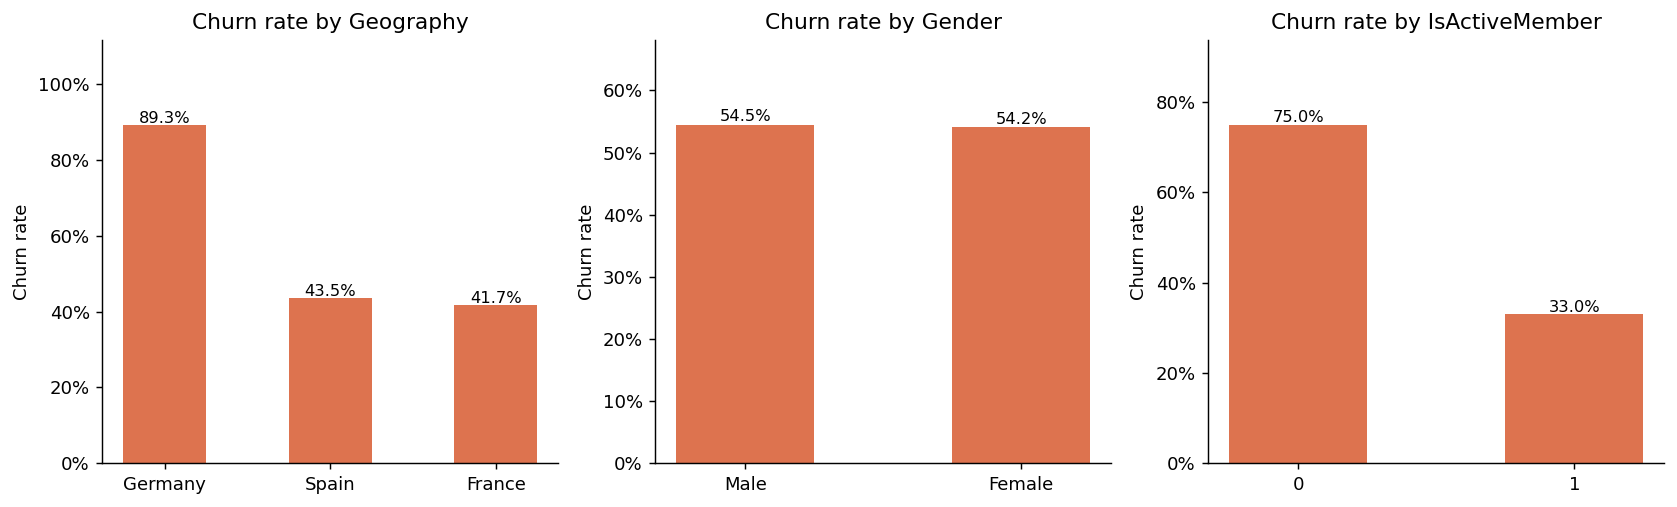

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

segments = {
    'Geography':       axes[0],
    'Gender':          axes[1],
    'IsActiveMember':  axes[2],
}

for col, ax in segments.items():
    rates = df.groupby(col)['Exited'].mean().sort_values(ascending=False)
    bars  = ax.bar(rates.index.astype(str), rates.values,
                   color=CHURN_COLOR, alpha=0.85, width=0.5)
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.set_ylim(0, rates.max() * 1.25)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/figures/01_churn_by_segment.png', bbox_inches='tight')
plt.show()

## 5. Correlation heatmap

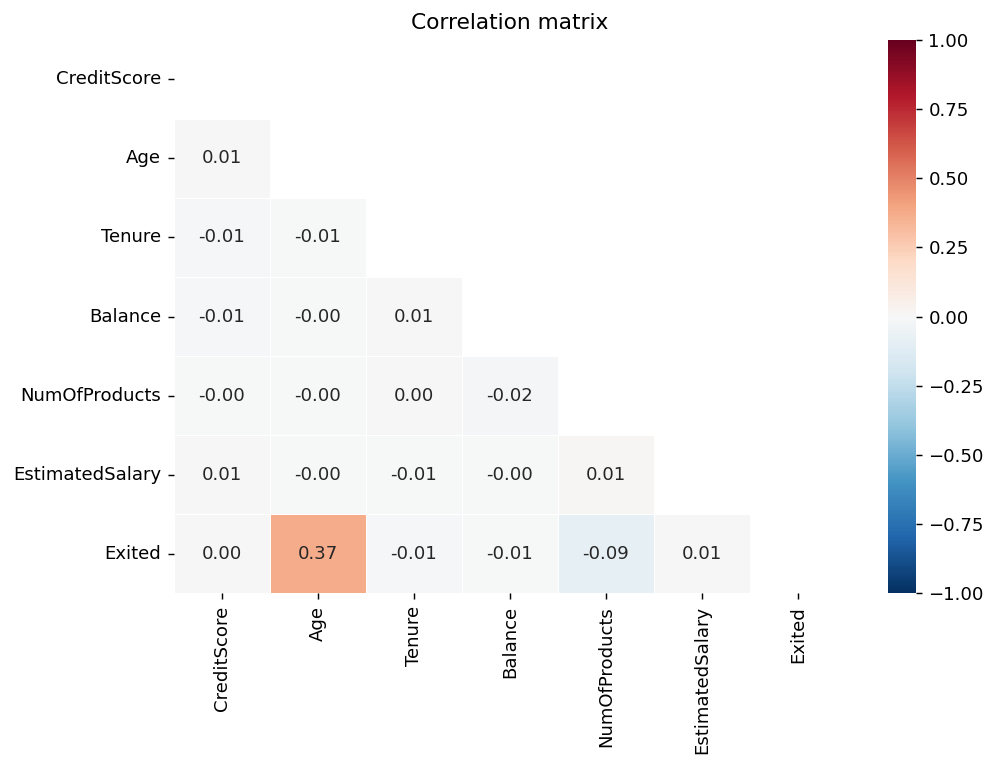

In [10]:
corr = df[numeric_cols + ['Exited']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.savefig('reports/figures/01_correlation.png', bbox_inches='tight')
plt.show()

## Save validated data

In [11]:
# Parquet preserves dtypes and loads faster than CSV in downstream notebooks
df.to_parquet('data/processed/df_validated.parquet', index=False)
print('Saved → data/processed/df_validated.parquet')

Saved → data/processed/df_validated.parquet
